In [2]:
import os; print(os.getcwd())

/Users/eprevot/Desktop/frugal-flows/validation


In [5]:
import sys, os
sys.path.append("./morphomnist") 

import numpy as np
import matplotlib.pyplot as plt
import jax.numpy as jnp

from prepare_data import prepare_flow_data, unflatten, inverse_logit

SIZE = 16
data = prepare_flow_data("morphomnist/data/", size=SIZE, n_samples=10000, seed=0)
{k: (v.shape if hasattr(v, "shape") else v) for k, v in data.items()}

{'Y': (10000, 256),
 'X': (10000, 1),
 'Z': (10000, 11),
 'Y0': (10000, 256),
 'Y1': (10000, 256),
 'ITE': (10000, 256),
 'ATE': (256,),
 'image_size': 16,
 'seed': 0}

Y1 and Y0 are the two potential outcomes under treatment or no treatement. If X=0, then Y=Y0 and viceversa

In [16]:
data.keys()

dict_keys(['Y', 'X', 'Z', 'Y0', 'Y1', 'ITE', 'ATE', 'image_size', 'seed'])

In [14]:
data["Y"]

Array([[-3.651383 , -3.5393066, -3.65699  , ..., -3.6077983, -3.567728 ,
        -3.5308626],
       [-3.6296382, -3.5878017, -3.6266909, ..., -3.538871 , -3.5524426,
        -3.6108823],
       [-3.6619642, -3.5673425, -3.600374 , ..., -3.544411 , -3.6228626,
        -3.5532658],
       ...,
       [-3.597325 , -3.5961568, -3.5863738, ..., -3.5413404, -3.6087368,
        -3.5539653],
       [-3.5321524, -3.628764 , -3.6056073, ..., -3.557846 , -3.636417 ,
        -3.5253806],
       [-3.648492 , -3.5994987, -3.5589302, ..., -3.628603 , -3.6524212,
        -3.5518725]], dtype=float32)

In [17]:
data["X"]

Array([[0.],
       [0.],
       [1.],
       ...,
       [0.],
       [1.],
       [1.]], dtype=float32)

ITE is supposed to be zero at the corners where there's no digit

max |ITE|: 0.83849645
nonzero fraction: 0.17704296875
per-unit nonzero pixels: [29 33 32 66 52 38 35 37 68 50]


Text(0.5, 1.0, 'mean |ITE| per pixel')

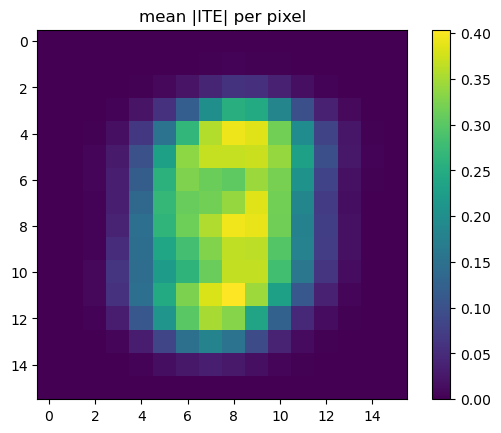

In [20]:
ITE = np.asarray(data["ITE"])
print("max |ITE|:", np.abs(ITE).max())
print("nonzero fraction:", (ITE != 0).mean())          # expect roughly the ink fraction, ~0.15–0.3
print("per-unit nonzero pixels:", (ITE != 0).sum(axis=1)[:10])
plt.imshow(np.abs(ITE).mean(axis=0).reshape(SIZE, SIZE)); plt.colorbar()
plt.title("mean |ITE| per pixel")  # should light up where digits are

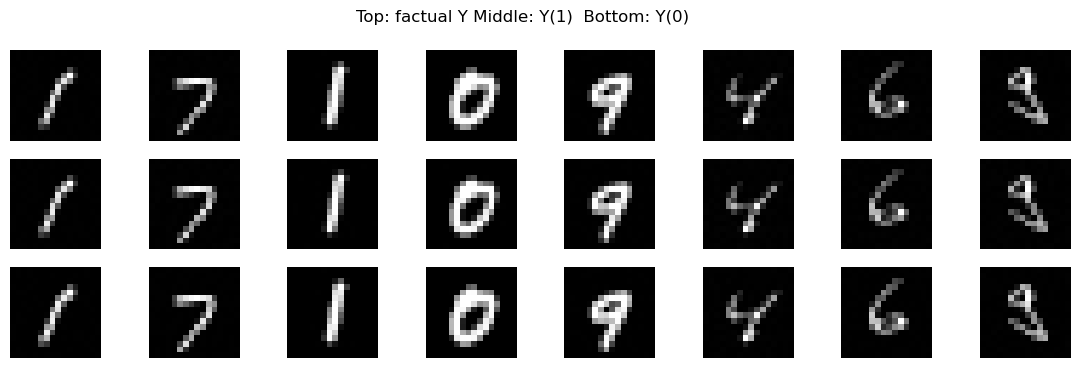

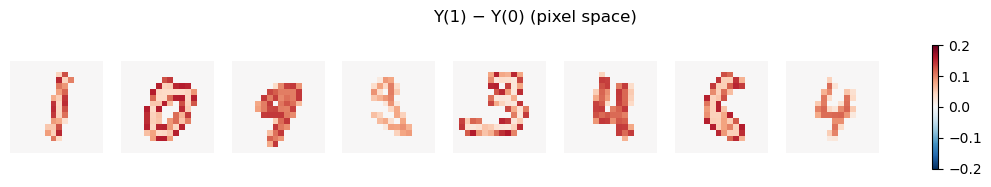

In [24]:
fig, axes = plt.subplots(3, 8, figsize=(14, 4))
imgs = inverse_logit(np.asarray(data["Y"][:8]))          # back to [0,1]
for i, ax in enumerate(axes[0]):
    ax.imshow(unflatten(imgs[i], SIZE)[0], cmap="gray"); ax.axis("off")
axes[0, 0].set_ylabel("factual", rotation=0)

# untreated potential outcome for the same units
imgs0 = inverse_logit(np.asarray(data["Y0"][:8]))
for i, ax in enumerate(axes[1]):
    ax.imshow(unflatten(imgs0[i], SIZE)[0], cmap="gray"); ax.axis("off")

# treated potential outcome for the same units
imgs1 = inverse_logit(np.asarray(data["Y1"][:8]))
for i, ax in enumerate(axes[2]):
    ax.imshow(unflatten(imgs1[i], SIZE)[0], cmap="gray"); ax.axis("off")
plt.suptitle("Top: factual Y Middle: Y(1)  Bottom: Y(0)")
plt.show()


T = np.asarray(data["X"]).flatten().astype(bool)
diff = inverse_logit(np.asarray(data["Y1"])) - inverse_logit(np.asarray(data["Y0"]))

idx = np.where(T)[0][:8]
fig, axes = plt.subplots(1, 8, figsize=(14, 2))
for i, ax in zip(idx, axes):
    im = ax.imshow(diff[i].reshape(SIZE, SIZE), cmap="RdBu_r",
                   vmin=-0.2, vmax=0.2)
    ax.axis("off")
plt.suptitle("Y(1) − Y(0) (pixel space)")
plt.colorbar(im, ax=axes, shrink=0.8)
plt.show()

treated fraction: 0.493


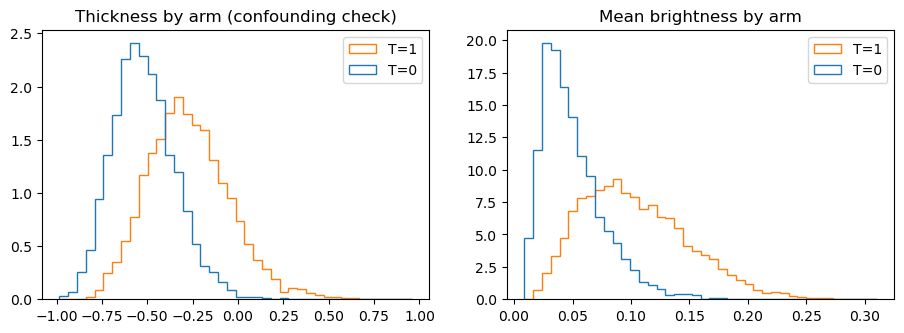

In [8]:
T = np.asarray(data["X"]).flatten()
thickness = np.asarray(data["Z"])[:, 0]
print(f"treated fraction: {T.mean():.3f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].hist([thickness[T==0], thickness[T==1]], bins=40, label=["T=0", "T=1"], density=True, histtype="step")
axes[0].legend(); axes[0].set_title("Thickness by arm (confounding check)")

# naive vs adjusted difference in mean brightness
mean_bright = inverse_logit(Y).mean(axis=1)
axes[1].hist([mean_bright[T==0], mean_bright[T==1]], bins=40, label=["T=0", "T=1"], density=True, histtype="step")
axes[1].legend(); axes[1].set_title("Mean brightness by arm")
plt.show()

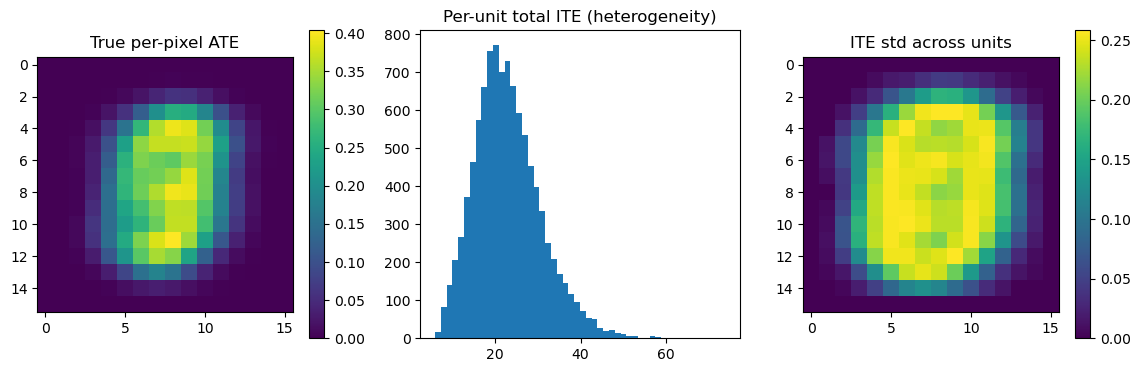

In [9]:
ATE = np.asarray(data["ATE"])           # (K,)
ITE = np.asarray(data["ITE"])           # (n, K)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
im = axes[0].imshow(ATE.reshape(SIZE, SIZE)); plt.colorbar(im, ax=axes[0])
axes[0].set_title("True per-pixel ATE")

axes[1].hist(ITE.sum(axis=1), bins=50)
axes[1].set_title("Per-unit total ITE (heterogeneity)")

im = axes[2].imshow(ITE.std(axis=0).reshape(SIZE, SIZE)); plt.colorbar(im, ax=axes[2])
axes[2].set_title("ITE std across units")
plt.show()

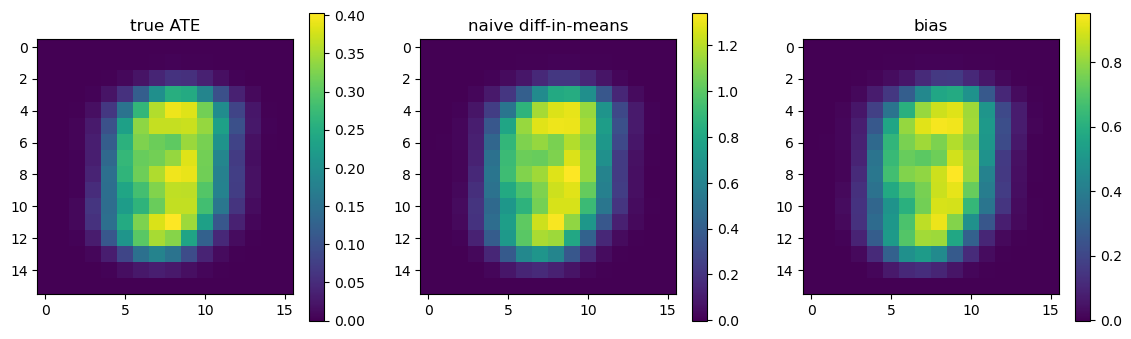

mean |bias| = 0.2186


In [10]:
# Naive per-pixel difference of means — biased because T is confounded
naive = Y[T==1].mean(axis=0) - Y[T==0].mean(axis=0)
true_flowspace = ITE.mean(axis=0)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, v, title in zip(axes, [true_flowspace, naive, naive - true_flowspace],
                        ["true ATE", "naive diff-in-means", "bias"]):
    im = ax.imshow(v.reshape(SIZE, SIZE)); plt.colorbar(im, ax=ax); ax.set_title(title)
plt.show()
print(f"mean |bias| = {np.abs(naive - true_flowspace).mean():.4f}")